In [2]:
def iter(path):

    from importlib import import_module
    import os
    import sys
    import argparse
    import linecache
    import uproot
    import vector
    import math
    import numpy as np
    import matplotlib.pyplot as plt
    import awkward as ak
    from tqdm import tqdm  # ✅ 진행률 표시
    import glob

    vector.register_awkward()
    
    file_list = sorted(glob.glob(path + "*11.root"))
    
    leading_muon_pt_list = []
    leading_flav_list = []
    subleading_muon_pt_list = []
    subleading_flav_list = []

    for sample in tqdm(file_list, desc="Processing files"):
        file = uproot.open(sample)
        events = file["Events"]
        keys = events.keys()
        hlt_mask = ((events["HLT_Mu50"].array() ==True) | (events["HLT_CascadeMu100"].array() ==True) | (events["HLT_HighPtTkMu100"].array() ==True)) & (events["Muon_highPtId"].array() ==2) & (events["Muon_tkIsoId"].array() ==2)
        #"pt"
        muon_pt = events["Muon_pt"].array()
        muon_pt = muon_pt[hlt_mask]
        morethan2muon = ak.num(muon_pt) > 1
        muon_pt = muon_pt[morethan2muon]
        first_muon = muon_pt[:,0:1]
        second_muon = muon_pt[:,1:2]
        muon_pt_mask = (first_muon[:,0] > 53) & (second_muon[:,0] > 30 )
        first_muons = first_muon[muon_pt_mask]
        second_muons = second_muon[muon_pt_mask]
        
        first_muons = ak.flatten(first_muons)
        second_muons = ak.flatten(second_muons)
        leading_muon_pt_list.append(first_muons)
        subleading_muon_pt_list.append(second_muons)

        # where is it from?
        muon_genflav = events["Muon_genPartFlav"].array()
        muon_genflav = muon_genflav[hlt_mask]
        morethan2muon_genflav = ak.num(muon_genflav) > 1
        muon_genflav = muon_genflav[morethan2muon_genflav]
        first_muon_genflav = muon_genflav[:,0:1]
        second_muon_genflav = muon_genflav[:,1:2]
        first_muon_genflav = first_muon_genflav[muon_pt_mask]
        second_muon_genflav = second_muon_genflav[muon_pt_mask]

        first_muon_genflav = ak.flatten(first_muon_genflav)
        second_muon_genflav = ak.flatten(second_muon_genflav)
        leading_flav_list.append(first_muon_genflav)
        subleading_flav_list.append(second_muon_genflav)
    return leading_muon_pt_list, subleading_muon_pt_list, leading_flav_list, subleading_flav_list




#plt.hist(first_muon_genflav[:,0], bins=10 , range= (-1,20), alpha=0.5, label="first muon genflav")
#plt.hist(second_muon_genflav[:,0], bins=10 , range=(-1,20), alpha=0.5, label="second muon genflav")
#plt.legend()


'''
genpart_mask = (events["GenPart_pdgId"].array() == 13) | (events["GenPart_pdgId"].array() == -13)
genmuon_pt = events["GenPart_pt"].array()[genpart_mask]
print("genmuon_pt", genmuon_pt)
genmuon_morethan2 = ak.num(genmuon_pt) > 1
genmuon_pt = genmuon_pt[genmuon_morethan2]
genmuon_pt_first = genmuon_pt[:,0:1]
genmuon_pt_second = genmuon_pt[:,1:2]

genmuon_pt_mask = (genmuon_pt_first[:,0] > 53) & (genmuon_pt_second[:,0] > 50 )

genmuon_pt_first = genmuon_pt_first[genmuon_pt_mask]
genmuon_pt_second = genmuon_pt_second[genmuon_pt_mask]

print(genmuon_pt_first)
print(genmuon_pt_second)

plt.hist(genmuon_pt_first[:,0], bins=100 , range=(0,1000), alpha=0.5, label="gen muon 1")
plt.hist(genmuon_pt_second[:,0], bins=100 , range=(0,1000), alpha=0.5, label="gen muon 2")
plt.legend()
plt.show()
'''





'''  
1  = prompt muon (W/Z → μ 등)
15 = muon from prompt tau (τ → μ)
5  = muon from b-quark (b → μ)
4  = muon from c-quark (c → μ)
3  = muon from light quark or unknown
0  = unmatched
'''


'  \n1  = prompt muon (W/Z → μ 등)\n15 = muon from prompt tau (τ → μ)\n5  = muon from b-quark (b → μ)\n4  = muon from c-quark (c → μ)\n3  = muon from light quark or unknown\n0  = unmatched\n'

In [3]:
sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/250609_062246/0000/" # ttlj
#sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8/250609_062251/0000/" # ttll
#sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/250617_130237/0000/NANOAOD_2.root" # tW
result=iter(sample)

Processing files: 100%|██████████| 10/10 [00:15<00:00,  1.56s/it]


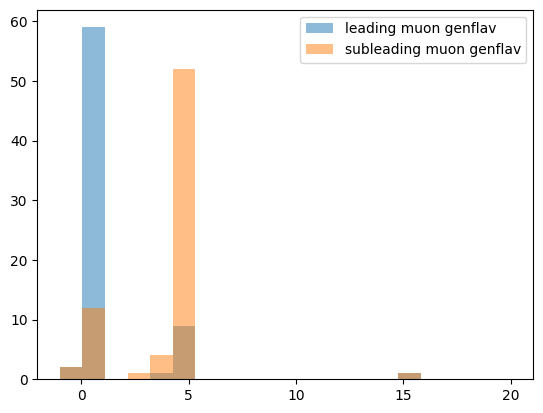

In [6]:
import matplotlib.pyplot as plt
import awkward as ak
plt.hist(ak.concatenate(result[2]), bins=20 , range=(-1,20), alpha=0.5, label="leading muon genflav")
plt.hist(ak.concatenate(result[3]), bins=20 , range=(-1,20), alpha=0.5, label="subleading muon genflav")
plt.legend()
plt.show()

#plt.hist(ak.concatenate(leading_flav_list), bins=20 , range=(-1,20), alpha=0.5, label="leading muon genflav")
#plt.hist(ak.concatenate(subleading_flav_list), bins=20 , range=(-1,20), alpha=0.5, label="subleading muon genflav")
#plt.legend()
#plt.show()

## why ttll is top tagged?


In [43]:
def iter(path):

    from importlib import import_module
    import os
    import sys
    import argparse
    import linecache
    import uproot
    import vector
    import math
    import numpy as np
    import matplotlib.pyplot as plt
    import awkward as ak
    from tqdm import tqdm  # ✅ 진행률 표시
    import glob

    vector.register_awkward()
    
    file_list = sorted(glob.glob(path + "*1.root"))
    
    leading_muon_pt_list = []
    leading_flav_list = []
    subleading_muon_pt_list = []
    subleading_flav_list = []

    toptag_list = []
    ratio32_list = []

    for sample in tqdm(file_list, desc="Processing files"):
        file = uproot.open(sample)
        events = file["Events"]
        keys = events.keys()
        hlt_mask = ((events["HLT_Mu50"].array() ==True) | (events["HLT_CascadeMu100"].array() ==True) | (events["HLT_HighPtTkMu100"].array() ==True)) & (events["Muon_highPtId"].array() ==2) & (events["Muon_tkIsoId"].array() ==2)
        #"pt"
        muon_pt = events["Muon_pt"].array()
        muon_pt = muon_pt[hlt_mask]
        morethan2muon = ak.num(muon_pt) > 1
        muon_pt = muon_pt[morethan2muon]
        first_muon = muon_pt[:,0:1]
        second_muon = muon_pt[:,1:2]
        muon_pt_mask = (first_muon[:,0] > 53) & (second_muon[:,0] > 30 )
        first_muons = first_muon[muon_pt_mask]
        second_muons = second_muon[muon_pt_mask]
        
        first_muons = ak.flatten(first_muons)
        second_muons = ak.flatten(second_muons)
        leading_muon_pt_list.append(first_muons)
        subleading_muon_pt_list.append(second_muons)

        # where is it from?
        muon_genflav = events["Muon_genPartFlav"].array()
        muon_genflav = muon_genflav[hlt_mask]
        morethan2muon_genflav = ak.num(muon_genflav) > 1
        muon_genflav = muon_genflav[morethan2muon_genflav]
        first_muon_genflav = muon_genflav[:,0:1]
        second_muon_genflav = muon_genflav[:,1:2]
        first_muon_genflav = first_muon_genflav[muon_pt_mask]
        second_muon_genflav = second_muon_genflav[muon_pt_mask]

        #first_muon_genflav = ak.flatten(first_muon_genflav)
        #second_muon_genflav = ak.flatten(second_muon_genflav)
        #leading_flav_list.append(first_muon_genflav)
        #subleading_flav_list.append(second_muon_genflav)


        topjet = events["FatJet_particleNetWithMass_TvsQCD"].array()
        #print("topjet", topjet)
        hlt_mask = ((events["HLT_Mu50"].array() ==True) | (events["HLT_CascadeMu100"].array() ==True) | (events["HLT_HighPtTkMu100"].array() ==True))
        morethan2muon_mask = ak.num(events["Muon_pt"].array()) > 1
        first_muon = events["Muon_pt"].array()[:,0:1]
        second_muon = events["Muon_pt"].array()[:,1:2]
        first_muon_mask = (events["Muon_highPtId"].array()[:,0:1] ==2) & (events["Muon_tkIsoId"].array()[:,0:1] ==2 )
        second_muon_mask = (events["Muon_highPtId"].array()[:,1:2] ==2) & (events["Muon_tkIsoId"].array()[:,1:2] ==2 )
        # 빈 array를 False로 채우기
        first_muon_mask = ak.pad_none(first_muon_mask, 1, axis=-1, clip=False)
        first_muon_mask = ak.fill_none(first_muon_mask, False)
        second_muon_mask = ak.pad_none(second_muon_mask, 1, axis=-1, clip=False)
        second_muon_mask = ak.fill_none(second_muon_mask, False)
        muon_mask = first_muon_mask & second_muon_mask
        #print("muon_mask", muon_mask)
        
        total_mask = hlt_mask & morethan2muon_mask & muon_mask
        first_muon = first_muon[total_mask]
        second_muon = second_muon[total_mask]
        
        # 첫 번째 원소를 안전하게 추출 (없으면 None)
        first_muon_pt = ak.firsts(first_muon, axis=-1)
        second_muon_pt = ak.firsts(second_muon, axis=-1)

        # None을 0으로 채우기 (pT cut에 걸리도록)
        first_muon_pt = ak.fill_none(first_muon_pt, 0)
        second_muon_pt = ak.fill_none(second_muon_pt, 0)

        muon_pt_mask = (first_muon_pt > 53) & (second_muon_pt > 30)
        total_mask = total_mask & muon_pt_mask
        total_mask = ak.fill_none(total_mask, False)
        total_mask = ak.flatten(total_mask)
        topjet = topjet[total_mask]
        # 비어있지 않은 수 확인 
        leftmask = ak.num(topjet) > 0
        topjets = topjet[leftmask]
        #print((topjets))
        
        # Check jet num inside fatjet 

        
        
        jet_eta = events["Jet_eta"].array()[total_mask]
        #print("jet_eta", jet_eta)
        #print(len(total_mask),total_mask)
        jet_num = (ak.num(jet_eta) == 0)
        #print("jet_num", len(jet_eta[jet_num]))
        jet_phi = events["Jet_phi"].array()[total_mask]
        
        jet_leftmask = (ak.num(jet_eta) > 1) & (ak.num(topjet) > 0)
        #print("jet_leftmask", len(jet_eta[jet_leftmask]))
        total_leftmask = jet_leftmask
        

        jet_eta = jet_eta[total_leftmask]
        jet_phi = jet_phi[total_leftmask]


        fatjet_eta = events["FatJet_eta"].array()[total_mask]
        fatjet_eta = fatjet_eta[total_leftmask]   

        fatjet_phi = events["FatJet_phi"].array()[total_mask]
        fatjet_phi = fatjet_phi[total_leftmask]

        #print("jet_eta", jet_eta ,len(jet_eta))
        #print("fatjet_eta", fatjet_eta, len(fatjet_eta))
        
        
        ### tau check 

        tau1 = events["FatJet_tau1"].array()[total_mask]
        tau2 = events["FatJet_tau2"].array()[total_mask]
        tau3 = events["FatJet_tau3"].array()[total_mask]
        tau4 = events["FatJet_tau4"].array()[total_mask]

        
        ratio32 = tau3 / tau2
        ratio32 = ratio32[leftmask]
        topjets = ak.flatten(topjets)
        ratio32 = ak.flatten(ratio32)
        
        print((topjets))
        print("ratio32", ratio32)
        toptag_list.append(topjets)
        ratio32_list.append(ratio32)




    return topjet,toptag_list, ratio32_list






Processing files:   0%|          | 0/100 [00:00<?, ?it/s]/home/achihwan/miniconda3/envs/hep-py-env/lib/python3.9/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
Processing files:   1%|          | 1/100 [00:01<02:34,  1.56s/it]

[0.629, 0.0427, 0.000895, 1.91e-05, 0.708, ..., 0.0489, 0.157, 0.233, 0.000532]
ratio32 [0.756, 0.708, 0.771, 0.581, 0.637, ..., 0.665, 0.558, 0.813, 0.841, 0.757]


Processing files:   2%|▏         | 2/100 [00:03<03:02,  1.86s/it]

[3.65e-06, 0.213, 0.422, 1.74e-07, 0.279, ..., 0.000494, 0.349, 0.245, 2.04e-06]
ratio32 [0.704, 0.853, 0.764, 0.783, 0.627, ..., 0.879, 0.708, 0.546, 0.771, 0.336]


Processing files:   3%|▎         | 3/100 [00:05<02:42,  1.67s/it]

...

Processing files:  99%|█████████▉| 99/100 [02:59<00:01,  1.77s/it]

[0.0718, 7.32e-06, 0.521, 0.054, 0.00622, ..., 0.000177, 6.34e-05, 8e-05, 0.674]
ratio32 [0.656, 0.709, 0.581, 0.717, 0.891, ..., 0.625, 0.79, 0.863, 0.626, 0.587]


Processing files: 100%|██████████| 100/100 [03:00<00:00,  1.81s/it]

[0.0412, 0.261, 5.75e-05, 9.73e-06, ..., 8.4e-05, 2.37e-06, 0.0161, 9.92e-07]
ratio32 [0.856, 0.698, 0.862, 0.879, 0.386, ..., 0.405, 0.867, 0.849, 0.785, 0.897]



/tmp/ipykernel_2613297/2261080874.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


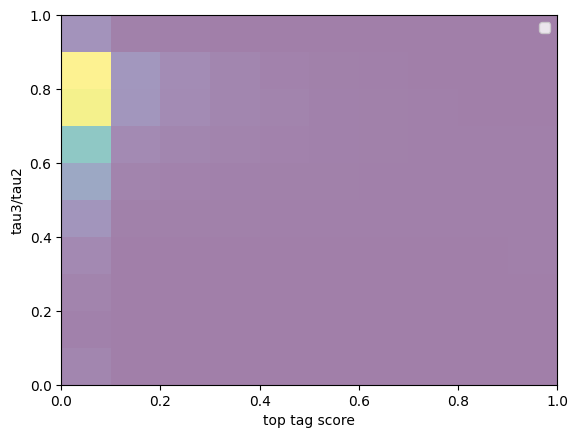

In [47]:
#sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/250609_062246/0000/" # ttlj
sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8/250609_062251/0000/" # ttll
#sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/250617_130237/0000/NANOAOD_2.root" # tW
result=iter(sample)
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np
#plt.hist(ak.concatenate(result), bins=50 , range=(0,1), alpha=0.5, label="topjet P(t|QCD)")

result1= ak.concatenate(result[1])
result2= ak.concatenate(result[2])
result1 = np.array(result1)
result2 = np.array(result2)
plt.hist2d(result1, result2, bins=10, alpha=0.5,range=[[0,1],[0,1]])
plt.xlabel("top tag score")
plt.ylabel("tau3/tau2")
plt.legend()
plt.show()

/tmp/ipykernel_2613297/3591957897.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


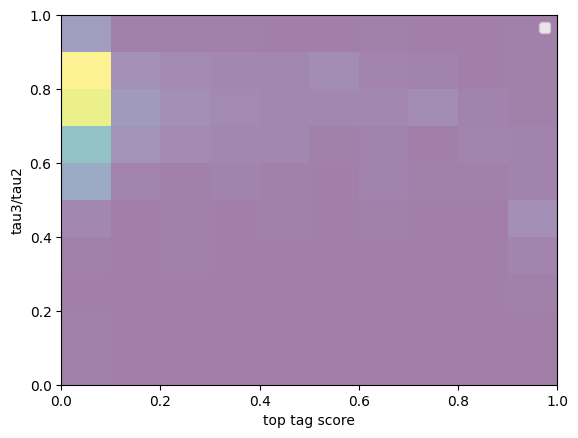

In [46]:
plt.hist2d(result1, result2, bins=10, alpha=0.5, range=[[0,1],[0,1]])
plt.xlabel("top tag score")
plt.ylabel("tau3/tau2")
plt.legend()
plt.show()

## where is l1 l2 from

In [ ]:
from importlib import import_module
import os
import sys
import argparse
import linecache
import uproot
import vector
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from tqdm import tqdm  # ✅ 진행률 표시
import glob
import json


vector.register_awkward()




def overlap_removal(target, cleans, cut=0.4, dphi=False):
    mask = ak.ones_like(target["pt"], dtype=bool)
    for clean in cleans:
        pairs = ak.cartesian([target, clean], nested=True)
        # ΔR 계산
        raw = (pairs["0"].deltaphi(pairs["1"]) if dphi else pairs["0"].deltaR(pairs["1"]))
        delta = np.abs(raw)
        # 0인 값(=자기 자신)을 무시하기 위해 np.inf로 대체
        nonzero = ak.where(delta > 0, delta, np.inf)
        # 이제 nonzero 중 최소값을 취함 → 사실상 두 번째로 작은 원래 delta
        min_dr = ak.min(nonzero, axis=2)
        mask = mask & (min_dr > cut)
    return target[mask]

def toptagging_overlap_removal(target, cleans, cut=0.8, dphi=False,events=None):
    toptagging = events["FatJet_particleNetWithMass_TvsQCD"].array()
    mask = ak.ones_like(target["pt"], dtype=bool)
    for clean in cleans:
        pairs = ak.cartesian([target, clean], nested=True)
        # ΔR 계산
        raw = (pairs["0"].deltaphi(pairs["1"]) if dphi else pairs["0"].deltaR(pairs["1"]))
        delta = np.abs(raw)
        # 0인 값(=자기 자신)을 무시하기 위해 np.inf로 대체
        nonzero = ak.where(delta > 0, delta, np.inf)
        # 이제 nonzero 중 최소값을 취함 → 사실상 두 번째로 작은 원래 delta
        min_dr = ak.min(nonzero, axis=2)
        mask = mask & (min_dr > cut)
    return toptagging[mask]

def sdm_toptagging_overlap_removal(target, cleans, cut=0.4, dphi=False,events=None):
    softdrop_mass = events["FatJet_msoftdrop"].array()
    mask = ak.ones_like(target["pt"], dtype=bool)
    for clean in cleans:
        pairs = ak.cartesian([target, clean], nested=True)
        # ΔR 계산
        raw = (pairs["0"].deltaphi(pairs["1"]) if dphi else pairs["0"].deltaR(pairs["1"]))
        delta = np.abs(raw)
        # 0인 값(=자기 자신)을 무시하기 위해 np.inf로 대체
        nonzero = ak.where(delta > 0, delta, np.inf)
        # 이제 nonzero 중 최소값을 취함 → 사실상 두 번째로 작은 원래 delta
        min_dr = ak.min(nonzero, axis=2)
        mask = mask & (min_dr > cut)
    return softdrop_mass[mask]


def overlap_itself_removal(target, cleans, cut=0.4, dphi=False):
            mask = ak.ones_like(target["pt"], dtype=bool)
            for clean in cleans:
                pairs = ak.cartesian([target, clean], nested=True) # axis 0 = #event , axis 1 = target , axis 2 = clean
                delta = np.abs(pairs["0"].deltaphi(pairs["1"]) if dphi else pairs["0"].deltaR(pairs["1"]))
                mask = mask & (ak.min(delta, axis=2) > cut)
            return target[mask]
def find_closest_jet(obj, jets):
    # obj, jets: both are jagged arrays of shape (n_events,), each sublist = Momentum4D
    pairs = ak.cartesian([obj, jets], nested=True)          # shape: (n_events, N_obj, N_jet)
    dr = pairs["0"].deltaR(pairs["1"])                       # same shape
    # 이벤트별로 obj 하나당 가장 작은 ΔR 의 jet index
    closest_idx_per_obj = ak.argmin(dr, axis=2)              # shape = (n_events, N_obj)
    return jets[closest_idx_per_obj]
def btag_find_closest_jet(obj, jets):
    # obj, jets: both are jagged arrays of shape (n_events,), each sublist = Momentum4D
    pairs = ak.cartesian([obj, jets], nested=True)          # shape: (n_events, N_obj, N_jet)
    dr = pairs["0"].deltaR(pairs["1"])                       # same shape
    # 이벤트별로 obj 하나당 가장 작은 ΔR 의 jet index
    closest_idx_per_obj = ak.argmin(dr, axis=2)              # shape = (n_events, N_obj)
    return btagging[closest_idx_per_obj]
def Select(inputcoll,etamax,ptmin) :
    output = []
    for obj in inputcoll :
        if abs(obj["eta"]) < etamax and obj["pt"] > ptmin : output.append(obj)
    return output 
def btag4_overlap_removal(target, cleans, cut=0.4, dphi=False,events=None):
    btag = events["Jet_btagPNetB"].array()
    #btag = events["Jet_btagDeepFlavB"].array()
    mask = ak.ones_like(target["pt"], dtype=bool)
    for clean in cleans:
        pairs = ak.cartesian([target, clean], nested=True)
        # ΔR 계산
        raw = (pairs["0"].deltaphi(pairs["1"]) if dphi else pairs["0"].deltaR(pairs["1"]))
        delta = np.abs(raw)
        # 0인 값(=자기 자신)을 무시하기 위해 np.inf로 대체
        nonzero = ak.where(delta > 0, delta, np.inf)
        # 이제 nonzero 중 최소값을 취함 → 사실상 두 번째로 작은 원래 delta
        min_dr = ak.min(nonzero, axis=2)
        mask = mask & (min_dr > cut)
    return btag[mask]

def ak8ak4(sample):


    file = uproot.open(sample)
    events = file["Events"]
    vector.register_awkward()
    keys = events.keys()
    

    # Reco-level
    ak4_eta = events["Jet_eta"].array()
    ak4_phi = events["Jet_phi"].array()
    ak4_pt = events["Jet_pt"].array()
    ak4_flavor = events["Jet_hadronFlavour"].array()
    ak4_mass = events["Jet_mass"].array()
    btag = events["Jet_btagPNetB"].array()

    ak4 = ak.zip({
        "pt": ak4_pt,
        "eta": ak4_eta,
        "phi": ak4_phi,
        "mass": ak4_mass
        }, with_name = "Momentum4D")
    
    fatjets = ak.zip({
        "pt":   events["FatJet_pt"].array(),
        "eta":  events["FatJet_eta"].array(),
        "phi":  events["FatJet_phi"].array(),
        "mass": events["FatJet_mass"].array()
    }, with_name="Momentum4D")
    reco_muons = ak.zip({
        "pt":   events["Muon_pt"].array(),
        "eta":  events["Muon_eta"].array(),
        "phi":  events["Muon_phi"].array(),
        "mass": events["Muon_mass"].array()
    }, with_name="Momentum4D")

    toptagging = events["FatJet_particleNetWithMass_TvsQCD"].array()
    softdrop_mass = events["FatJet_msoftdrop"].array()
    
    # Clean b-jet
    #print("reco_muons", reco_muons)
    first_muon = reco_muons[:, 0:1]  # 첫 번째 뮤온
    second_muon = reco_muons[:, 1:2]  # 두 번째 뮤온
    sortidx_muon = ak.argsort(-reco_muons["pt"], axis=1)  # pt 기준으로 내림차순 정렬
    first_muon = reco_muons[sortidx_muon][:, 0:1]  # 가장 큰 pt를 가진 뮤온
    second_muon = reco_muons[sortidx_muon][:, 1:2]  # 두 번째로 큰 pt를 가진 뮤온


    muon_iso = events["Muon_tkIsoId"].array() 
    muon_highpt_id = events["Muon_highPtId"].array()

    leading_muon_iso = muon_iso[sortidx_muon][:, 0:1]
    leading_muon_hpt = muon_highpt_id[sortidx_muon][:, 0:1]
    subleading_muon_iso = muon_iso[sortidx_muon][:, 1:2]
    subleading_muon_hpt = muon_highpt_id[sortidx_muon][:, 1:2]

    first_muon_cleaned  = first_muon
    second_muon_cleaned = second_muon

    # Clean top-jet
    toptag_scores    = toptagging_overlap_removal(fatjets, [first_muon_cleaned, second_muon_cleaned,fatjets], cut=0.8,events=events)
    softdrop_masses  = sdm_toptagging_overlap_removal(fatjets, [first_muon_cleaned, second_muon_cleaned,fatjets], cut=0.8, events=events)
    signaltop_cleaned = overlap_removal(fatjets, [first_muon_cleaned, second_muon_cleaned, fatjets], cut=0.8)
    mask_top         = (toptag_scores > 0.9) #& (softdrop_masses > 120) & (softdrop_masses < 250)
    top_jets         = signaltop_cleaned[mask_top]
    leading_toptag_ak8 = top_jets[ak.argsort(-top_jets["pt"], axis=1)][:, 0:1]

    signalb_cleaned = overlap_removal(ak4, [first_muon_cleaned,second_muon_cleaned,leading_toptag_ak8, ak4], cut=0.4)
    #btaggedb_cleaned = btag4_overlap_removal(ak4, [first_muon_cleaned,second_muon_cleaned, leading_toptag_ak8,ak4], cut=0.4, events=events)


    sortidx = ak.argsort(-signalb_cleaned["pt"], axis=1)  # pt 기준으로 내림차순 정렬
    signalb_cleaend_sorted = signalb_cleaned[sortidx][:, 0:1]  # 가장 큰 pt를 가진 jet만 선택
    #sorted_btaggedb_cleaned = btaggedb_cleaned[sortidx][:, 0:1]  # 가장 큰 pt를 가진 jet에 대한 b-tag 정보 선택
    #sorted_btaggedb_cleaned2 = btaggedb_cleaned[sortidx][:, 1:2]  # 가장 큰 pt를 가진 jet에 대한 b-tag 정보 선택


    #btagging = sorted_btaggedb_cleaned > 0.6734 # particle net
    #btagging = sorted_btaggedb_cleaned > 0.7183 # deepjet
    #leading_tagged_bjet = signalb_cleaend_sorted[btagging]
    #sortidx = ak.argsort(-signalb_cleaend_sorted["pt"], axis=1)  # pt 기준으로 내림차순 정렬
    #leading_tagged_bjet = signalb_cleaend_sorted[sortidx][:, 0:1]  # 가장 큰 pt를 가진 jet만 선택

    

    # Event-level mask
    pt1 = ak.sum(first_muon_cleaned["pt"], axis=1)
    pt2 = ak.sum(second_muon_cleaned["pt"], axis=1)
    ptb = ak.sum(signalb_cleaend_sorted["pt"], axis=1)
    ptt = ak.sum(leading_toptag_ak8["pt"], axis=1)
    eta1 =ak.sum(first_muon_cleaned["eta"], axis=1)
    eta2 = ak.sum(second_muon_cleaned["eta"], axis=1)

    hlt = ((events["HLT_Mu50"].array() ==True) | (events["HLT_CascadeMu100"].array() ==True) | (events["HLT_HighPtTkMu100"].array() ==True))
    #print(leading_muon_hpt)
    muon_id_mask = (
    (ak.firsts(leading_muon_hpt) == 2) & 
    (ak.firsts(subleading_muon_hpt) == 2) & 
    (ak.firsts(leading_muon_iso) == 2) & 
    (ak.firsts(subleading_muon_iso) == 2)
    )

    evt_mask = (
        (pt1 > 53) & (pt2 > 30) &
        (ptb > 30) & (ptt > 350) 
    )

    hlt_mask = (
        (pt1 > 0) & (pt2 > 0) &
        (ptb > 0) & (ptt > 0) & (hlt==True)
    )

    final_mask = muon_id_mask & evt_mask & hlt_mask

    lmi = leading_muon_iso[evt_mask]
    lmhpt = leading_muon_hpt[evt_mask]
    slmi = subleading_muon_iso[evt_mask]
    slhpt = subleading_muon_hpt[evt_mask]

    #fm1 = first_muon_cleaned[evt_mask]
    #fm2 = second_muon_cleaned[evt_mask]
    #lb  = leading_tagged_bjet[evt_mask]
    #lt  = leading_toptag_ak8[evt_mask]
    
    fm1 = first_muon_cleaned[final_mask]
    fm2 = second_muon_cleaned[final_mask]
    lb  = signalb_cleaend_sorted[final_mask]
    lt  = leading_toptag_ak8[final_mask]
    #print(ak.flatten(softdrop_masses[ak.flatten(softdrop_masses)>0]))
    sdm = softdrop_masses[final_mask]
    #print(sdm)
    
    muon_genflav = events["Muon_genPartFlav"].array()
    muon_genflav = muon_genflav[final_mask]
    
    muon_genflav1 = muon_genflav[:,0:1]
    muon_genflav2 = muon_genflav[:,1:2]
    
    #print("muon genflav 1", (muon_genflav1))
    # Final vars
    combined_p4   = (fm1 + fm2 + lb + lt).mass
    mN            = (fm1 + lb + lt).mass
    mu1_pt_flat   = ak.flatten(fm1["pt"])
    mu2_pt_flat   = ak.flatten(fm2["pt"])
    lt_flat       = ak.flatten(lt["pt"])
    lb_flat       = ak.flatten(lb["pt"])
    
    
    
    


    return combined_p4, mN, mu1_pt_flat, mu2_pt_flat,lt_flat,lb_flat ,lmi , slmi, lmhpt, slhpt ,sdm ,muon_genflav1, muon_genflav2

def iter_allfile (path):
    from importlib import import_module
    import os
    import sys
    import argparse
    import linecache
    import uproot
    import vector
    import math
    import numpy as np
    import matplotlib.pyplot as plt
    import awkward as ak
    from tqdm import tqdm  # ✅ 진행률 표시
    import glob
    
    file_list = sorted(glob.glob(path + "*11.root"))
    
    combined_p4_list = []
    lb_list = []
    lt_list = []
    mu1_pt_list = []
    mu2_pt_list = []
    lmi_list = []
    lmh_list = []
    smi_list = []
    smh_list = []
    btag_list = []
    sdm_list = []
    muon_genflav1_list = []
    muon_genflav2_list = []
    totalev_list = 0
    leftev_list = 0
    hltpassev_list = 0

    # tqdm으로 파일 리스트 순회
    for sample in tqdm(file_list, desc="Processing ROOT files"):

        combined_p4, mN, mu1_pt, mu2_pt,lt,lb,lmi,lmh,smi,smh,sdm,genflav1,genflav2 = ak8ak4(sample)

        combined_p4_list.append(combined_p4)
        mu1_pt_list.append(mu1_pt)
        mu2_pt_list.append(mu2_pt)
        lt_list.append(lt)
        lb_list.append(lb)
        lmi_list.append(lmi)
        lmh_list.append(lmh)
        smi_list.append(smi)
        smh_list.append(smh)
        sdm_list.append(sdm)
        muon_genflav1_list.append(genflav1)
        muon_genflav2_list.append(genflav2)
    return (combined_p4_list, mu1_pt_list, mu2_pt_list,lt_list,lb_list, lmi_list, lmh_list, smi_list, smh_list, btag_list,sdm_list,muon_genflav1_list, muon_genflav2_list)
            # 0. combined_p4_list
            # 2. mu1_pt_list
            # 3. mu2_pt_list
            # 4. lt_list
            # 5. lb_list
            # 6. lmi_list
            # 7. lmh_list
            # 8. smi_list
            # 9. smh_list
            # 10. btag_list
            # 11. totalev_list
            # 12. leftev_list
            # 13. hltpassev_list





In [21]:
#sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TTtoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/250609_062246/0000/" # ttlj
sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TTto2L2Nu_TuneCP5_13p6TeV_powheg-pythia8/250609_062251/0000/" # ttll
#sample = "/gv0/DATA/SKNano/Run3NanoAODv13p1/2022EE/TbarWplustoLNu2Q_TuneCP5_13p6TeV_powheg-pythia8/250617_130237/0000/NANOAOD_2.root" # tW
#sample ="/gv0/Users/achihwan/SKNano/Run3NanoAODv13p1/2022/WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV/Run3Summer22NanoAODv12_WRtoNMutoMuMuTB-HadTop_MWR-3000_MN-1300_13p6TeV_" # signal

result=iter_allfile(sample)



Processing ROOT files:   0%|          | 0/10 [00:00<?, ?it/s]

reco_muons [[], ..., [{pt: 39.2, eta: -1.09, phi: -0.587, mass: 0.106}, {...}, ..., {...}]]


Processing ROOT files:  10%|█         | 1/10 [00:03<00:28,  3.14s/it]

reco_muons [[], [], ..., [{...}, ...], [{pt: 30.7, eta: 2.37, phi: 0.963, mass: 0.106}]]


Processing ROOT files:  20%|██        | 2/10 [00:10<00:44,  5.59s/it]

...

Processing ROOT files:  80%|████████  | 8/10 [00:33<00:06,  3.27s/it]

reco_muons [[{pt: 54.2, eta: -0.988, phi: -0.76, mass: 0.106}, ..., {pt: 6.78, ...}], ...]


Processing ROOT files:  90%|█████████ | 9/10 [00:35<00:03,  3.05s/it]

reco_muons [[], ..., [{pt: 17.1, eta: 0.723, phi: 1.83, mass: 0.106}, {pt: ..., ...}]]


Processing ROOT files: 100%|██████████| 10/10 [00:38<00:00,  3.85s/it]


In [22]:
a=(ak.flatten(result[-1]))
b=(ak.flatten(result[-2]))



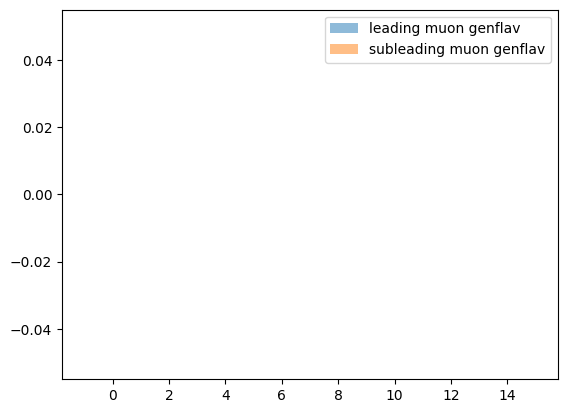

In [23]:
plt.hist(b, bins=16 , range=(-1,15), alpha=0.5, label="leading muon genflav")
plt.hist(a, bins=16 , range=(-1,15), alpha=0.5, label="subleading muon genflav")
plt.legend()